<a href="https://colab.research.google.com/github/Blue-Jay-Walker/Statistics-Concepts/blob/main/Copy_of_CAS_ML_Project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CAS ETH in ML in Finance and Insurance**
# Project 1: Credit Analytics --THIS IS THE MAIN DELIVERABLE***
****BE CAREFUL WITH YOUR CHANGES and MAKE A COPY TO PLAY around****

### Team members:** Kristina Danielson, Jay Modi, Andrea Covini, Patrick Leone**

---

Excercise 0 - Import and initialize the seed

In [1]:
### Import all the Python libraries you are going to use

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.io as pio

In [2]:
### Fix random seed for reproducibility
# (i.e. every time you run this you get the same data)
np.random.seed(42)

Step 1 - We're inventing 30,000 fictional loan applicants, each with three characteristics:


*   Their age (randomly between 18 and 80
*   Their monthly income in CHF thousands (randomly between 1 and 15)
*   Whether they are salaried or self-employed (90% chance salaried, 10% self-employed)

Step 2 - Then for each person we calculate their probability of defaulting on a loan using two different mathematical formulas (p₁ and p₂),

p1(x) = ψ(−13.3 + 0.33x1−3.5x2 + 3x3) => Linear function

p2(x) = ψ−5 + 10 1(−∞,25)(x1) + 1(75,∞)(x1)−1.1x2 + x3 => Non-Linear function

Let ψ: R →(0,1) be the logistic function (also known as the sigmoid function) given by

$$\psi(z) = \frac{e^z}{1 + e^z} = \frac{1}{1 + e^{-z}}$$


Where each borrower gets a "risk score" based on their age, income and employment. That score can be any number (positive or negative). The sigmoid squashes it into a number between 0 and 1, which we can interpret as a probability. For example, a score might become 0.23, meaning "23% chance of defaulting."

Step 3 - We flip a weighted coin to decide if they actually default (1) or not (0)

The coin flip uses that probability (This is the np.random.binomial(n=1, p=prob) line of code)

Once we know someone has a 23% default probability, we flip a weighted coin that lands on "default" 23% of the time. The outcome (0 or 1) is the actual label in the dataset.




# Exercise 1. Dataset features generation.

In [3]:
# Here write your code to generate the dataset features
# ------------------------------------------------------------
# PART 1: Generate the borrower features
# ------------------------------------------------------------

m = 20000   # number of training samples
n = 10000   # number of test samples
total = m + n  # 30,000 borrowers in total

# Feature 1: Age - uniformly distributed between 18 and 80
age = np.random.uniform(18, 80, size=total)
np.round(age, 0, out=age)

# Feature 2: Monthly income in CHF thousands - uniformly between 1 and 15
income = np.random.uniform(1, 15, size=total)
np.round(income, 2, out=income)

# Feature 3: Employment status - 0 = salaried, 1 = self-employed
# 10% chance of being self-employed
employment = np.random.binomial(n=1, p=0.1, size=total)
np.round(employment, 2, out=employment)

# Stack the three features into a matrix X with shape (30000, 3)
X = np.column_stack([age, income, employment])

print(X[0:10])

[[41.    9.93  0.  ]
 [77.    7.43  0.  ]
 [63.   14.5   0.  ]
 [55.    4.07  0.  ]
 [28.    9.23  0.  ]
 [28.   10.8   0.  ]
 [22.   12.56  0.  ]
 [72.    6.7   0.  ]
 [55.   10.62  0.  ]
 [62.    5.24  0.  ]]


# Exercise 2. Dataset labels generation.

In [4]:
from google.colab import files


# Here write your code to generate the dataset labels

# ------------------------------------------------------------
# PART 2: Calculate default probabilities and generate labels
# ------------------------------------------------------------

# The sigmoid (logistic) function: squashes any number into a value between 0 and 1
# Think of it as converting a "risk score" into a probability
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# --- Default probability formula 1 (linear/logistic regime) ---
# This is a straightforward logistic regression style formula:
# - Older borrowers have HIGHER default risk (+0.33 * age)
# - Higher income means LOWER default risk (-3.5 * income)
# - Self-employed have HIGHER default risk (+3 * employment)
def p1(x):
    z = -13.3 + 0.33 * x[:, 0] - 3.5 * x[:, 1] + 3 * x[:, 2]
    return sigmoid(z)

# --- Default probability formula 2 (non-linear regime) ---
# This is trickier - very young (<25) AND very old (>75) borrowers
# both have higher default risk (the indicator functions handle this)
# This is what makes dataset 2 harder for logistic regression to capture
def p2(x):
    age_col = x[:, 0]
    income_col = x[:, 1]
    emp_col = x[:, 2]

    # Indicator: 1 if age < 25, else 0
    young = (age_col < 25).astype(float)
    # Indicator: 1 if age > 75, else 0
    old = (age_col > 75).astype(float)

    z = -5 + 10 * (young + old) - 1.1 * income_col + emp_col
    return sigmoid(z)

# Compute the default probabilities for all 30,000 borrowers
prob1 = p1(X)
np.round(prob1, 2, out=prob1)

prob2 = p2(X)
np.round(prob2, 2, out=prob2)

# --- Generate binary labels (1 = defaulted, 0 = did not default) ---
# For each borrower, we flip a weighted coin using their default probability
# np.random.binomial with n=1 is exactly a weighted coin flip
y1 = np.random.binomial(n=1, p=prob1)
np.round(y1, 2, out=y1)

y2 = np.random.binomial(n=1, p=prob2)
np.round(y2, 2, out=y2)

# ------------------------------------------------------------
# Split into training and test sets
# ------------------------------------------------------------



# Build a tidy dataframe for splitting, tabulation and plotting
df = pd.DataFrame({
    'Age':              age,
    'Income (CHF k)':  income,
    'Self-Employed':   employment,
    'Default Prob p1': prob1,
    'Default Prob p2': prob2,
    'Default y1':      y1,
    'Default y2':      y2,
})

#print("the official DF")
#print(df[0:10])



#-- Export the generated data as CSV.
# ── 2. Define filename ───────────────────────────────────────────────────────
filename = "project1_Credit_data.csv" #--to prevent overwriting the original data

# ── 3. Export to CSV (in Colab session storage) ──────────────────────────────
#df.to_csv(filename, index=False, encoding="utf-8-sig")  # utf-8-sig ensures Excel compatibility
#print(f"✅ Saved '{filename}' to session storage ({len(df)} rows, {len(df.columns)} cols)")

# ── 4. Download to your local COLLAB ────────────────────────────────────────
#files.download(filename)
#print("⬇️  Browser download triggered.")

**Data Visualization based on the generated test data**

In [5]:
# ============================================================
# DATA CHARACTERIZATION TABLE
# - Overall default summary (y1 & y2)
# - Age × Income cross-tab: count + % of defaults
# ============================================================
#from google.colab import drive
#drive.mount('/content/drive/CAS-ML')

# ============================================================
# STEP 0:Reload data# csv for subsequent steps in the same/other notebooks ───
# ============================================================

filename = "project1_Credit_data.csv"
df_reloaded = pd.read_csv(filename)  # from session.

# ============================================================
# STEP 1: SPLITTING of Training and TEST Dataset — Overall Default Summary of TEST AND TRAINING DATASETS
# ============================================================
df_Train = df_reloaded.iloc[:m].copy()
df_Test = df_reloaded.iloc[m:].copy()

print("=" * 60)
print("Dataset Splitting completed:")
print("Training:" + str(len(df_Train)))
print("Test:    " + str(len(df_Test)))
print("=" * 60)
print(" " * 60)

total      = len(df_Train)
d1_count   = int(df_Train['Default y1'].sum())
d2_count   = int(df_Train['Default y2'].sum())
both_count = int(((df_Train['Default y1'] == 1) & (df_Train['Default y2'] == 1)).sum())

summary = pd.DataFrame({
    'Metric':       ['Count', 'Percent (%)'],
    '|Total':        [total,   '100.00%'],
    '|Default y1': [d1_count,   f"{round(d1_count   / total * 100, 2)}%"],
    '|Default y2': [d2_count,   f"{round(d2_count   / total * 100, 2)}%"],
    '|y1 AND y2':  [both_count, f"{round(both_count / total * 100, 2)}%"],
})

print("=" * 60)
print("  SECTION 1a — TRAINING DATA DEFAULT SUMMARY")
print("=" * 60)
print(summary.to_string(index=False))
print(" " * 60)

total      = len(df_Test)
d1_count   = int(df_Test['Default y1'].sum())
d2_count   = int(df_Test['Default y2'].sum())
both_count = int(((df_Test['Default y1'] == 1) & (df_Train['Default y2'] == 1)).sum())

summary = pd.DataFrame({
    'Metric':       ['Count', 'Percent (%)'],
    '|Total':        [total,   '100.00%'],
    '|Default y1': [d1_count,   f"{round(d1_count   / total * 100, 2)}%"],
    '|Default y2': [d2_count,   f"{round(d2_count   / total * 100, 2)}%"],
    '|y1 AND y2':  [both_count, f"{round(both_count / total * 100, 2)}%"],
})

print("=" * 60)
print("  SECTION 1b — TEST DATA DEFAULT SUMMARY")
print("=" * 60)
print(summary.to_string(index=False))
print(" " * 60)


# ============================================================
# STEP 2: Age Buckets (10-year) & Income Buckets (CHF 2k)
# ============================================================
age_bins   = [17, 30, 40, 50, 60, 70, 80, 90, 100]
age_labels = ['18-30','31-40','41-50','51-60','61-70','71-80','81-90','91-100']
df['Age Group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels)

income_step   = 2   # CHF k — change this value to adjust bucket width
income_min    = int(df['Income (CHF k)'].min() // income_step) * income_step
income_max    = int(df['Income (CHF k)'].max() // income_step + 1) * income_step
income_bins   = list(range(income_min, income_max + income_step, income_step))
income_labels = [f'{b}-{b+income_step}k' for b in income_bins[:-1]]
df['Income Group'] = pd.cut(df['Income (CHF k)'], bins=income_bins, labels=income_labels)


# ============================================================
# STEP 3: SECTION 2 — Age × Income Cross-Tabulation
# Builds a multi-level column table:
#   For each income bucket → count of y1=1, % y1=1, count of y2=1, % y2=1
# ============================================================
grp = df.groupby(['Age Group', 'Income Group'], observed=True)

ct_total  = grp.size().unstack('Income Group').fillna(0).astype(int)
ct_y1     = grp['Default y1'].sum().unstack('Income Group').fillna(0).astype(int)
ct_y2     = grp['Default y2'].sum().unstack('Income Group').fillna(0).astype(int)

# Percentage: count of defaults / total rows in that cell
ct_y1_pct = (ct_y1 / ct_total.replace(0, np.nan) * 100).round(2).fillna(0)
ct_y2_pct = (ct_y2 / ct_total.replace(0, np.nan) * 100).round(2).fillna(0)

# Build combined display: "count (x.xx%)"  for each cell
def fmt_cell(count_df, pct_df):
    """Returns a DataFrame with 'N (x.xx%)' strings."""
    return count_df.astype(str) + " (" + pct_df.astype(str) + "%)"

combined_y1 = fmt_cell(ct_y1, ct_y1_pct)
combined_y2 = fmt_cell(ct_y2, ct_y2_pct)

# ---- Print Default y1 cross-tab ----
print("\n" + "=" * 60)
print("  SECTION 2a — DEFAULT y1=1  |  Count (%) per Age × Income")
print("  Rows = Age Group | Columns = Income Bucket (CHF k)")
print("=" * 60)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 300)
pd.set_option('display.max_colwidth', 15)
print(combined_y1.to_string())

# ---- Print Default y2 cross-tab ----
print("\n" + "=" * 60)
print("  SECTION 2b — DEFAULT y2=1  |  Count (%) per Age × Income")
print("  Rows = Age Group | Columns = Income Bucket (CHF k)")
print("=" * 60)
print(combined_y2.to_string())



Dataset Splitting completed:
Training:20000
Test:    10000
                                                            
  SECTION 1a — TRAINING DATA DEFAULT SUMMARY
     Metric  |Total |Default y1 |Default y2 |y1 AND y2
      Count   20000        1004         973        270
Percent (%) 100.00%       5.02%       4.87%      1.35%
                                                            
  SECTION 1b — TEST DATA DEFAULT SUMMARY
     Metric  |Total |Default y1 |Default y2 |y1 AND y2
      Count   10000         522         469          0
Percent (%) 100.00%       5.22%       4.69%       0.0%
                                                            

  SECTION 2a — DEFAULT y1=1  |  Count (%) per Age × Income
  Rows = Age Group | Columns = Income Bucket (CHF k)
Income Group          0-2k          2-4k        4-6k      6-8k     8-10k    10-12k    12-14k    14-16k
Age Group                                                                                             
18-30             0 (0.


Generating pairplot for Dataset 1 (p1 regime)...


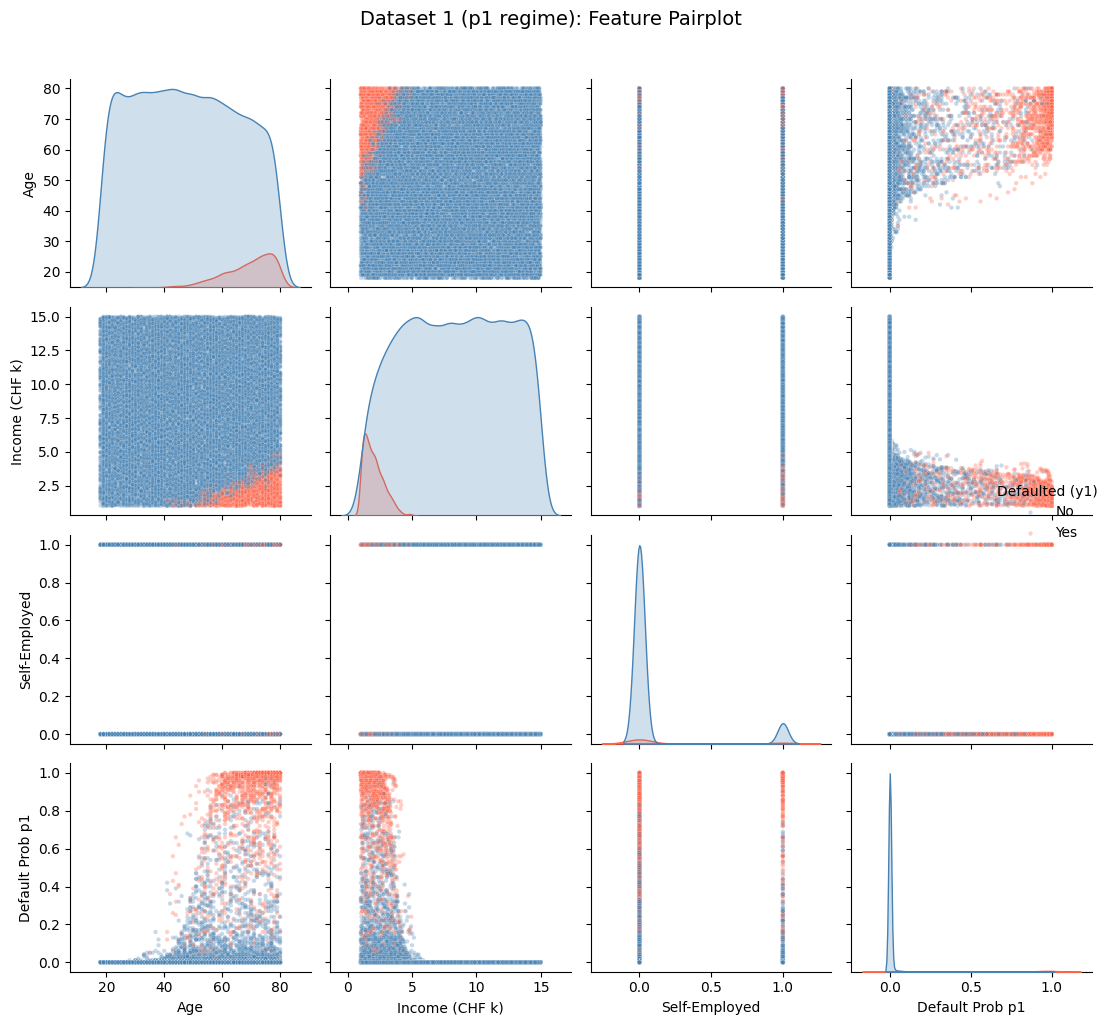

Saved: pairplot_dataset1.png


In [6]:

# --- Pairplot for Dataset 1 ---
print("\nGenerating pairplot for Dataset 1 (p1 regime)...")
subset1 = df[['Age', 'Income (CHF k)', 'Self-Employed', 'Default Prob p1']].copy()
subset1['Defaulted (y1)'] = df['Default y1'].map({0: 'No', 1: 'Yes'})

g1 = sns.pairplot(
    subset1,
    hue='Defaulted (y1)',
    vars=['Age', 'Income (CHF k)', 'Self-Employed', 'Default Prob p1'],
    palette={'No': 'steelblue', 'Yes': 'tomato'},
    plot_kws={'alpha': 0.3, 's': 10},
    diag_kind='kde'
)
g1.figure.suptitle('Dataset 1 (p1 regime): Feature Pairplot', y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig('pairplot_dataset1.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: pairplot_dataset1.png")

In [8]:
# ============================================================
# HEATMAP – Default Prob I + Total / Employed / Self-Employed
# Blue = Lowest Risk | Crimson = Highest Risk
# Tile: p=prob | n=total (E=Employed  SE=Self-Employed)
# Compatible with Google Colab
# ============================================================


# ============================================================
# STEP 2: Age & Income Buckets
# ============================================================
age_bins   = [17, 30, 40, 50, 60, 70, 80, 90, 100]
age_labels = ['18-30','31-40','41-50','51-60','61-70','71-80','81-90','91-100']
df['Age Group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels)

income_step   = 2   # CHF k – change to 2 for CHF 2k steps
income_min    = int(df['Income (CHF k)'].min() // income_step) * income_step
income_max    = int(df['Income (CHF k)'].max() // income_step + 1) * income_step
income_bins   = list(range(income_min, income_max + income_step, income_step))
income_labels = [f'{b}-{b+income_step}k' for b in income_bins[:-1]]
df['Income Group'] = pd.cut(df['Income (CHF k)'], bins=income_bins, labels=income_labels)

# ============================================================
# STEP 3: Four pivots — prob / total / employed / self-employed  ← NEW
# ============================================================
grp = df.groupby(['Age Group', 'Income Group'], observed=True)

pivot_prob  = grp['Default Prob p1'].mean().unstack('Income Group')
pivot_count = grp['Default Prob p1'].count().unstack('Income Group')
pivot_emp   = grp['Self-Employed'].apply(lambda x: (x == 0).sum()).unstack('Income Group')  # ← NEW
pivot_self  = grp['Self-Employed'].apply(lambda x: (x == 1).sum()).unstack('Income Group')  # ← NEW

idx  = pivot_prob.index
cols = pivot_prob.columns

z_prob  = pivot_prob.values
z_count = pivot_count.reindex(index=idx, columns=cols).values
z_emp   = pivot_emp.reindex(index=idx, columns=cols).values   # ← NEW
z_self  = pivot_self.reindex(index=idx, columns=cols).values  # ← NEW

x = [str(c) for c in cols]
y = [str(r) for r in idx]

# ============================================================
# STEP 4: Cell text – 2-line label with all counts  ← CHANGED
# Line 1: p=0.52
# Line 2: n=14 (E:10 SE:4)
# ============================================================
rows, ncols = z_prob.shape
cell_text = [
    [
        (f'p={z_prob[r][c]:.2f}<br>'
         f'n={int(z_count[r][c])} '
         f'(E:{int(z_emp[r][c])} SE:{int(z_self[r][c])})')
        if not np.isnan(z_prob[r][c]) else ''
        for c in range(ncols)
    ]
    for r in range(rows)
]

# Pass all three count arrays into customdata for hover  ← NEW
customdata = np.stack([z_count, z_emp, z_self], axis=-1)

# ============================================================
# STEP 5: Color Scale — Blue (low) → Crimson (high)
# ============================================================
colorscale = [
    [0.00, '#1a78c2'],
    [0.25, '#6aafd6'],
    [0.50, '#f5e9e5'],
    [0.75, '#d94f3a'],
    [1.00, '#dc143c'],
]

# ============================================================
# STEP 6: Build Heatmap
# ============================================================
fig = go.Figure(go.Heatmap(
    z=z_prob,
    x=x,
    y=y,
    colorscale=colorscale,
    colorbar=dict(title=dict(text='Default Prob', side='right'), thickness=14),
    customdata=customdata,
    text=cell_text,
    texttemplate='%{text}',
    textfont=dict(size=8),
    hovertemplate=(                              # ← CHANGED – full breakdown on hover
        '<b>Age:</b> %{y}<br>'
        '<b>Income:</b> %{x}<br>'
        '<b>Default Prob:</b> %{z:.2f}<br>'
        '<b>Total Records:</b> %{customdata[0]:.0f}<br>'
        '<b>Employed:</b> %{customdata[1]:.0f}<br>'
        '<b>Self-Employed:</b> %{customdata[2]:.0f}'
        '<extra></extra>'
    ),
))

fig.update_layout(
    title=dict(
        text="Default Probability (p1) by Age & Income Group<br>"
             "<span style='font-size:13px;font-weight:normal'>"
             "p = mean prob | n = total (E = Employed, SE = Self-Employed)</span>",
        x=0.5, xanchor='center', font=dict(size=17)
    ),
    width=1200, height=600,
    margin=dict(t=85, b=130, l=110, r=90),
)
fig.update_xaxes(title_text='Income Group (CHF k)', tickangle=-45,
                 tickfont=dict(size=11), title_standoff=25)
fig.update_yaxes(title_text='Age Group', tickfont=dict(size=11), title_standoff=15)

fig.show()

# Optional: save as PNG
# fig.write_image("heatmap_default_prob.png")

In [9]:
# ============================================================
# HEATMAP – Default Prob I + Total / Employed / Self-Employed
# Blue = Lowest Risk | Crimson = Highest Risk
# Tile: p=prob | n=total (E=Employed  SE=Self-Employed)
# Compatible with Google Colab
# ============================================================


# ============================================================
# STEP 2: Age & Income Buckets
# ============================================================
age_bins   = [17, 30, 40, 50, 60, 70, 80, 90, 100]
age_labels = ['18-30','31-40','41-50','51-60','61-70','71-80','81-90','91-100']
df['Age Group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels)

income_step   = 2   # CHF k – change to 2 for CHF 2k steps
income_min    = int(df['Income (CHF k)'].min() // income_step) * income_step
income_max    = int(df['Income (CHF k)'].max() // income_step + 1) * income_step
income_bins   = list(range(income_min, income_max + income_step, income_step))
income_labels = [f'{b}-{b+income_step}k' for b in income_bins[:-1]]
df['Income Group'] = pd.cut(df['Income (CHF k)'], bins=income_bins, labels=income_labels)

# ============================================================
# STEP 3: Four pivots — prob / total / employed / self-employed  ← NEW
# ============================================================
grp = df.groupby(['Age Group', 'Income Group'], observed=True)

pivot_prob  = grp['Default Prob p2'].mean().unstack('Income Group')
pivot_count = grp['Default Prob p2'].count().unstack('Income Group')
pivot_emp   = grp['Self-Employed'].apply(lambda x: (x == 0).sum()).unstack('Income Group')  # ← NEW
pivot_self  = grp['Self-Employed'].apply(lambda x: (x == 1).sum()).unstack('Income Group')  # ← NEW

idx  = pivot_prob.index
cols = pivot_prob.columns

z_prob  = pivot_prob.values
z_count = pivot_count.reindex(index=idx, columns=cols).values
z_emp   = pivot_emp.reindex(index=idx, columns=cols).values   # ← NEW
z_self  = pivot_self.reindex(index=idx, columns=cols).values  # ← NEW

x = [str(c) for c in cols]
y = [str(r) for r in idx]

# ============================================================
# STEP 4: Cell text – 2-line label with all counts  ← CHANGED
# Line 1: p=0.52
# Line 2: n=14 (E:10 SE:4)
# ============================================================
rows, ncols = z_prob.shape
cell_text = [
    [
        (f'p={z_prob[r][c]:.2f}<br>'
         f'n={int(z_count[r][c])} '
         f'(E:{int(z_emp[r][c])} SE:{int(z_self[r][c])})')
        if not np.isnan(z_prob[r][c]) else ''
        for c in range(ncols)
    ]
    for r in range(rows)
]

# Pass all three count arrays into customdata for hover  ← NEW
customdata = np.stack([z_count, z_emp, z_self], axis=-1)

# ============================================================
# STEP 5: Color Scale — Blue (low) → Crimson (high)
# ============================================================
colorscale = [
    [0.00, '#1a78c2'],
    [0.25, '#6aafd6'],
    [0.50, '#f5e9e5'],
    [0.75, '#d94f3a'],
    [1.00, '#dc143c'],
]

# ============================================================
# STEP 6: Build Heatmap
# ============================================================
fig = go.Figure(go.Heatmap(
    z=z_prob,
    x=x,
    y=y,
    colorscale=colorscale,
    colorbar=dict(title=dict(text='Default Prob', side='right'), thickness=14),
    customdata=customdata,
    text=cell_text,
    texttemplate='%{text}',
    textfont=dict(size=8),
    hovertemplate=(                              # ← CHANGED – full breakdown on hover
        '<b>Age:</b> %{y}<br>'
        '<b>Income:</b> %{x}<br>'
        '<b>Default Prob:</b> %{z:.2f}<br>'
        '<b>Total Records:</b> %{customdata[0]:.0f}<br>'
        '<b>Employed:</b> %{customdata[1]:.0f}<br>'
        '<b>Self-Employed:</b> %{customdata[2]:.0f}'
        '<extra></extra>'
    ),
))

fig.update_layout(
    title=dict(
        text="Default Probability (P2) by Age & Income Group<br>"
             "<span style='font-size:13px;font-weight:normal'>"
             "p = mean prob | n = total (E = Employed, SE = Self-Employed)</span>",
        x=0.5, xanchor='center', font=dict(size=17)
    ),
    width=1200, height=600,
    margin=dict(t=85, b=130, l=110, r=90),
)
fig.update_xaxes(title_text='Income Group (CHF k)', tickangle=-45,
                 tickfont=dict(size=11), title_standoff=25)
fig.update_yaxes(title_text='Age Group', tickfont=dict(size=11), title_standoff=15)

fig.show()

# Optional: save as PNG
# fig.write_image("heatmap_default_prob.png")


Generating pairplot for Dataset 2 (p2 regime)...


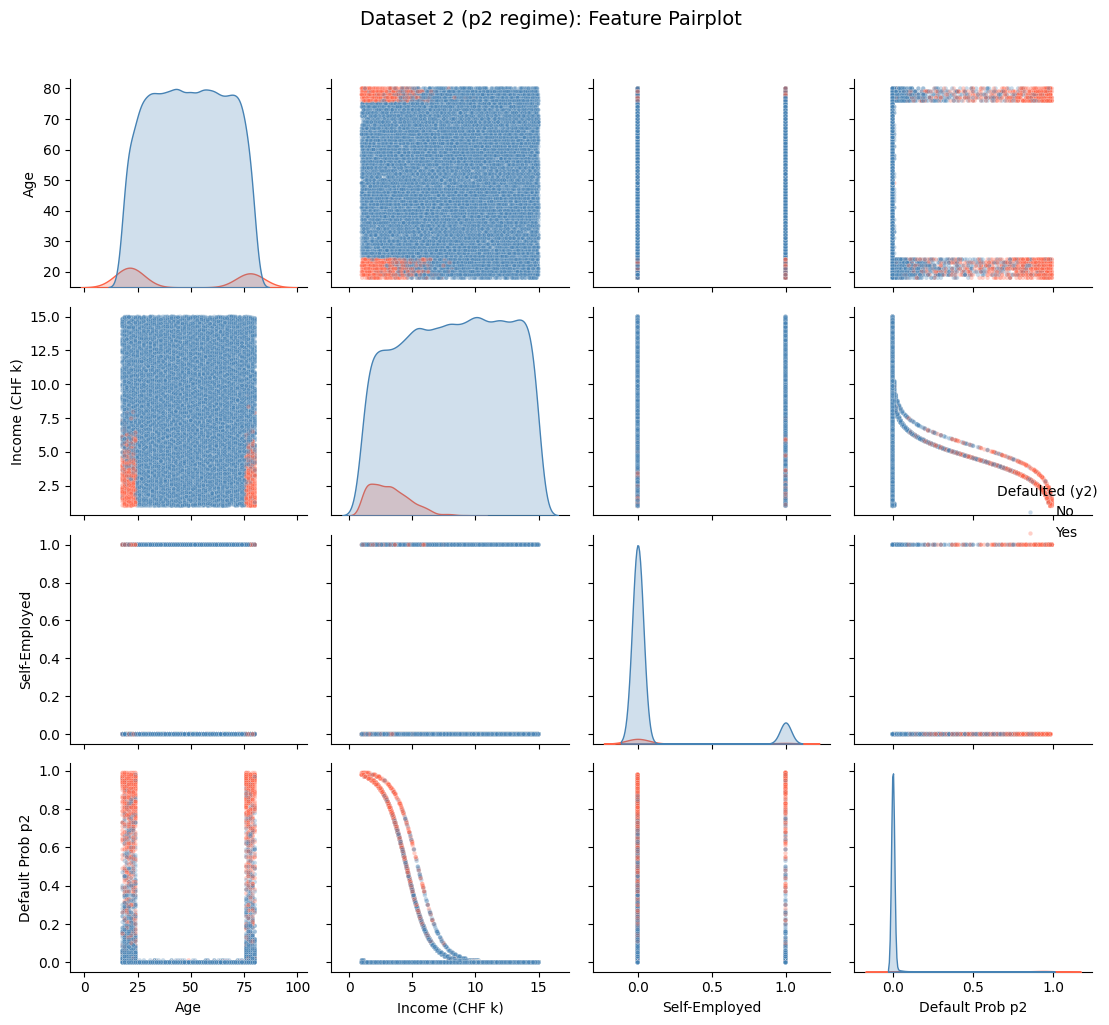

Saved: pairplot_dataset2.png

Generating default probability vs age plot for Dataset 2...


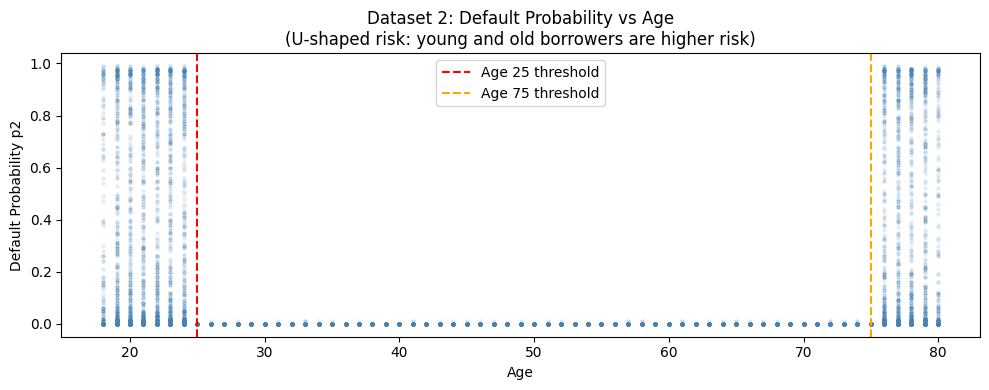

Saved: p2_vs_age.png

Data generation complete. All variables ready for model fitting in Part 3.


In [11]:


# --- Pairplot for Dataset 2 ---
print("\nGenerating pairplot for Dataset 2 (p2 regime)...")
subset2 = df[['Age', 'Income (CHF k)', 'Self-Employed', 'Default Prob p2']].copy()
subset2['Defaulted (y2)'] = df['Default y2'].map({0: 'No', 1: 'Yes'})

g2 = sns.pairplot(
    subset2,
    hue='Defaulted (y2)',
    vars=['Age', 'Income (CHF k)', 'Self-Employed', 'Default Prob p2'],
    palette={'No': 'steelblue', 'Yes': 'tomato'},
    plot_kws={'alpha': 0.3, 's': 10},
    diag_kind='kde'
)
g2.figure.suptitle('Dataset 2 (p2 regime): Feature Pairplot', y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig('pairplot_dataset2.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: pairplot_dataset2.png")

# --- Additional analysis: Default probability vs Age for Dataset 2 ---
# This plot nicely shows the U-shape (young and old = higher risk)
print("\nGenerating default probability vs age plot for Dataset 2...")
plt.figure(figsize=(10, 4))
plt.scatter(age, prob2, alpha=0.1, s=5, color='steelblue')
plt.axvline(25, color='red', linestyle='--', label='Age 25 threshold')
plt.axvline(75, color='orange', linestyle='--', label='Age 75 threshold')
plt.xlabel('Age')
plt.ylabel('Default Probability p2')
plt.title('Dataset 2: Default Probability vs Age\n(U-shaped risk: young and old borrowers are higher risk)')
plt.legend()
plt.tight_layout()
plt.savefig('p2_vs_age.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: p2_vs_age.png")

print("\nData generation complete. All variables ready for model fitting in Part 3.")



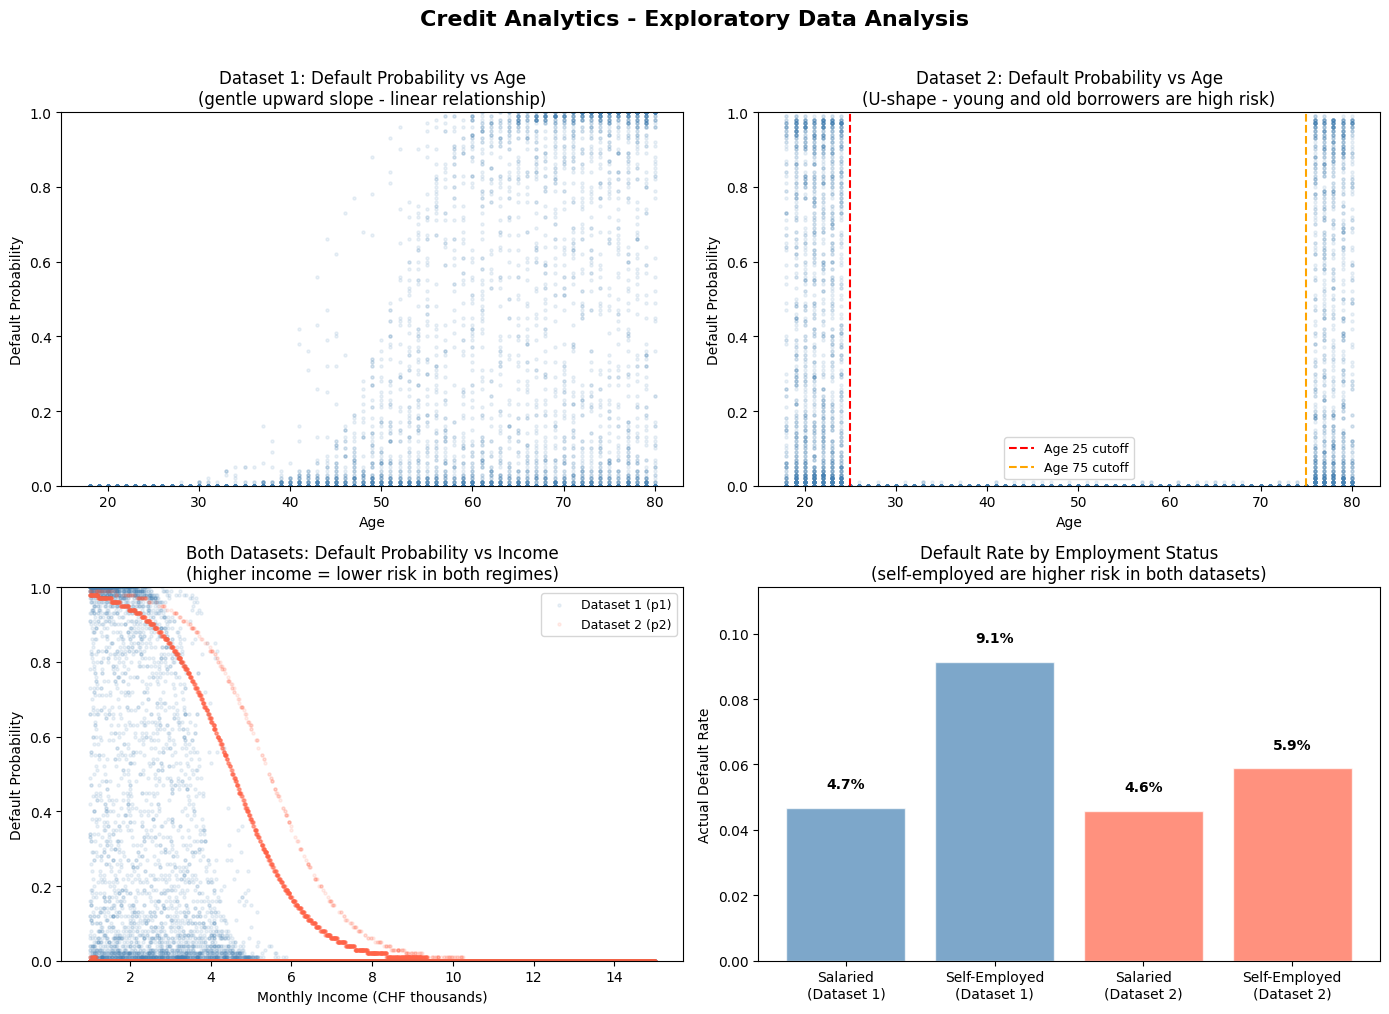

Saved: credit_analytics_eda.png


In [12]:
# ============================================================
# Part 2: Focused Exploratory Plots for Report
# ============================================================
# NOTE: Run this code AFTER the data generation code block
# All variables (age, income, employment, prob1, prob2, y1, y2)
# must already exist in your Colab session
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Credit Analytics - Exploratory Data Analysis', fontsize=16, fontweight='bold', y=1.01)

# ------------------------------------------------------------
# Plot 1 (top left): Default probability p1 vs Age
# Expected: a gentle upward slope - older = more risk
# ------------------------------------------------------------
ax = axes[0, 0]
ax.scatter(age, prob1, alpha=0.1, s=5, color='steelblue')
ax.set_xlabel('Age')
ax.set_ylabel('Default Probability')
ax.set_title('Dataset 1: Default Probability vs Age\n(gentle upward slope - linear relationship)')
ax.set_ylim(0, 1)

# ------------------------------------------------------------
# Plot 2 (top right): Default probability p2 vs Age
# Expected: U-shape - young (<25) and old (>75) are high risk
# ------------------------------------------------------------
ax = axes[0, 1]
ax.scatter(age, prob2, alpha=0.1, s=5, color='steelblue')
ax.axvline(25, color='red', linestyle='--', linewidth=1.5, label='Age 25 cutoff')
ax.axvline(75, color='orange', linestyle='--', linewidth=1.5, label='Age 75 cutoff')
ax.set_xlabel('Age')
ax.set_ylabel('Default Probability')
ax.set_title('Dataset 2: Default Probability vs Age\n(U-shape - young and old borrowers are high risk)')
ax.set_ylim(0, 1)
ax.legend(fontsize=9)

# ------------------------------------------------------------
# Plot 3 (bottom left): Default probability vs Income
# Expected: clear downward slope for both datasets
# Higher income = lower default risk
# ------------------------------------------------------------
ax = axes[1, 0]
ax.scatter(income, prob1, alpha=0.1, s=5, color='steelblue', label='Dataset 1 (p1)')
ax.scatter(income, prob2, alpha=0.1, s=5, color='tomato', label='Dataset 2 (p2)')
ax.set_xlabel('Monthly Income (CHF thousands)')
ax.set_ylabel('Default Probability')
ax.set_title('Both Datasets: Default Probability vs Income\n(higher income = lower risk in both regimes)')
ax.set_ylim(0, 1)
ax.legend(fontsize=9)

# ------------------------------------------------------------
# Plot 4 (bottom right): Default rates by employment status
# Expected: self-employed (1) have higher default rates than salaried (0)
# ------------------------------------------------------------
ax = axes[1, 1]

# Calculate average default RATE (not probability) for each group
salaried_mask = (employment == 0)
selfempl_mask  = (employment == 1)

categories = ['Salaried\n(Dataset 1)', 'Self-Employed\n(Dataset 1)',
              'Salaried\n(Dataset 2)', 'Self-Employed\n(Dataset 2)']
values = [
    y1[salaried_mask].mean(),
    y1[selfempl_mask].mean(),
    y2[salaried_mask].mean(),
    y2[selfempl_mask].mean()
]
colors = ['steelblue', 'steelblue', 'tomato', 'tomato']
bars = ax.bar(categories, values, color=colors, alpha=0.7, edgecolor='white')

# Add percentage labels on top of each bar
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.005,
            f'{val:.1%}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Actual Default Rate')
ax.set_title('Default Rate by Employment Status\n(self-employed are higher risk in both datasets)')
ax.set_ylim(0, max(values) * 1.25)

plt.tight_layout()
plt.savefig('credit_analytics_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: credit_analytics_eda.png")


# Exercise 3. Model implementations.

### 3a) Logistic regression (LR)

The following section covers the following:

1. Training of the LR Model on training data
2. Evaluation of the Model on TRAINING data (incl ROC and loss for comparision/verification at later stage)
3. Evaluation of the Model on TEST data (incl ROC and loss for comparision/verification at later stage)

4. Visualizing the Regression Divide (Decision Boundaries) on Training and Test Data.


DATASET Training Y1 and Y2 - Logistic Regression

  MODEL: Default y1  |  penalty=None
                precision    recall  f1-score   support

No Default (0)       1.00      0.97      0.98     18996
   Default (1)       0.61      0.99      0.75      1004

      accuracy                           0.97     20000
     macro avg       0.80      0.98      0.87     20000
  weighted avg       0.98      0.97      0.97     20000

  ROC-AUC Score: 0.9968
  Actual Defaults:   1004
  Predicted Defaults: 1636
  Actual Non-Defaults: 18996
  Predicted Non-Defaults: 18364

  MODEL: Default y2  |  penalty=None
                precision    recall  f1-score   support

No Default (0)       0.99      0.75      0.85     19027
   Default (1)       0.15      0.88      0.26       973

      accuracy                           0.75     20000
     macro avg       0.57      0.81      0.55     20000
  weighted avg       0.95      0.75      0.82     20000

  ROC-AUC Score: 0.8665
  Actual Defaults:    973
  Predict

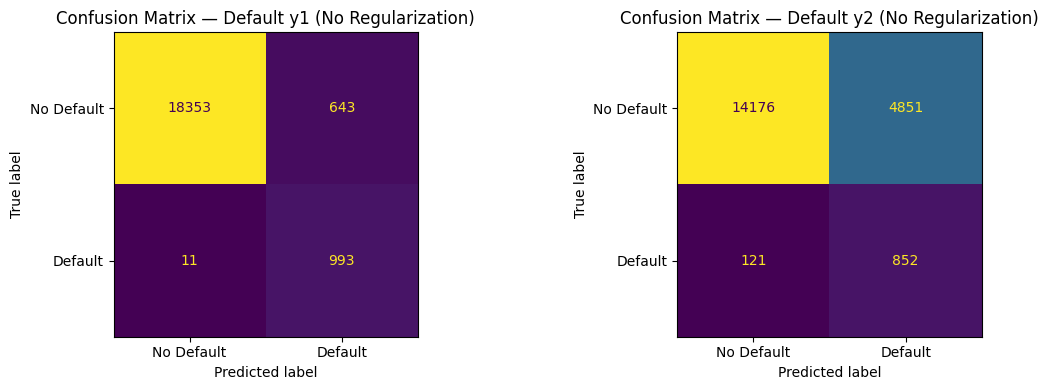

  CROSS-ENTROPY LOSS SUMMARY  (DF_train)
    Target  Cross-Entropy Loss
Default y1            1.178627
Default y2            8.960452


In [13]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, roc_curve, auc
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Fit logistic regression on Dataset 1
# ------------------------------------------------------------
print("="*55)
print("DATASET Training Y1 and Y2 - Logistic Regression")
print("="*55)


# ============================================================
# STEP 1: Define Features (X) and Targets (y)
# ============================================================
FEATURE_COLS = ['Age', 'Income (CHF k)', 'Self-Employed']

TARGET_Y1    = 'Default y1'
TARGET_Y2    = 'Default y2'

X_train = df_Train[FEATURE_COLS]
y1_train = df_Train[TARGET_Y1]
y2_train = df_Train[TARGET_Y2]

# ============================================================
# STEP 3a: Individual Models — NO REGULARIZATION  ← CHANGED
# ============================================================
model_y1 = LogisticRegression(
    penalty=None,
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

model_y2 = LogisticRegression(
    penalty=None,
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

model_y1.fit(X_train, y1_train)
model_y2.fit(X_train, y2_train)

# ============================================================
# STEP 4: Predictions on Training Data
# Replace X_train_scaled with scaler.transform(X_test) for
# evaluation on unseen data
# ============================================================
y1_pred       = model_y1.predict(X_train)
y1_pred_proba = model_y1.predict_proba(X_train)[:, 1]  # P(Default y1=1)

y2_pred       = model_y2.predict(X_train)
y2_pred_proba = model_y2.predict_proba(X_train)[:, 1]  # P(Default y2=1)

# ============================================================
# STEP 5: Evaluation
# ============================================================
for label, y_true, y_pred, y_proba in [
    ('Default y1', y1_train, y1_pred, y1_pred_proba),
    ('Default y2', y2_train, y2_pred, y2_pred_proba),
]:
    print(f"\n{'='*55}")
    print(f"  MODEL: {label}  |  penalty=None")
    print(f"{'='*55}")
    print(classification_report(y_true, y_pred,
                                 target_names=['No Default (0)', 'Default (1)']))
    print(f"  ROC-AUC Score: {roc_auc_score(y_true, y_proba):.4f}")
    print(f"  Actual Defaults: {y_true.sum():>6}")
    print(f"  Predicted Defaults: {y_pred.sum():>3}")
    print(f"  Actual Non-Defaults: {(y_true == 0).sum():>2}")
    print(f"  Predicted Non-Defaults: {(y_pred == 0).sum():>2}")

# ============================================================
# STEP 6: Confusion Matrices (visual)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, label, y_true, y_pred in [
    (axes[0], 'Default y1', y1_train, y1_pred),
    (axes[1], 'Default y2', y2_train, y2_pred),
]:
    ConfusionMatrixDisplay(
        confusion_matrix(y_true, y_pred),
        display_labels=['No Default', 'Default']
    ).plot(ax=ax, colorbar=False)
    ax.set_title(f'Confusion Matrix — {label} (No Regularization)')

plt.tight_layout()
plt.show()

# ============================================================
# STEP 7: Add predicted probabilities back to DF_train
# ============================================================
#df_Train['y1_pred']       = y1_pred
#df_Train['y1_pred_proba'] = np.round(y1_pred_proba, 4)
#df_Train['y2_pred']       = y2_pred
#df_Train['y2_pred_proba'] = np.round(y2_pred_proba, 4)

#print("\n✅ Predicted labels and probabilities added to DF_train.")
#print(df_Train[['Default y1', 'y1_pred', 'y1_pred_proba',
#                 'Default y2', 'y2_pred', 'y2_pred_proba']].head(10))


# ============================================================
# STEP 8: Compute Binary Cross-Entropy Loss per target
#
# ============================================================
ce_y1 = log_loss(y1_train, y1_pred)
ce_y2 = log_loss(y2_train, y2_pred)

# ============================================================
# STEP 9: Summary Table
# ============================================================
ce_summary = pd.DataFrame({
    'Target':              ['Default y1', 'Default y2'],
    'Cross-Entropy Loss':  [round(ce_y1, 6), round(ce_y2, 6)],
})

print("=" * 45)
print("  CROSS-ENTROPY LOSS SUMMARY  (DF_train)")
print("=" * 45)
print(ce_summary.to_string(index=False))

In [ ]:
display(df.head())

,Age,Income (CHF k),Self-Employed,Default Prob p1,Default Prob p2,Default y1,Default y2,Age Group,Income Group
0,41.0,9.93,0,0.0,0.00,0,0,41-50,8-10k
1,77.0,7.43,0,0.0,0.04,0,0,71-80,6-8k
2,63.0,14.50,0,0.0,0.00,0,0,61-70,14-16k
3,55.0,4.07,0,0.0,0.00,0,0,51-60,4-6k
4,28.0,9.23,0,0.0,0.00,0,0,18-30,8-10k


DATASET TEST Y1 and Y2 - Logistic Regression

  MODEL: Default y1  |  penalty=None
                precision    recall  f1-score   support

No Default (0)       1.00      0.97      0.99      9478
   Default (1)       0.67      0.99      0.80       522

      accuracy                           0.97     10000
     macro avg       0.84      0.98      0.89     10000
  weighted avg       0.98      0.97      0.98     10000

  ROC-AUC Score: 0.9978
  Actual Defaults:    522
  Predicted Defaults: 772
  Actual Non-Defaults: 9478
  Predicted Non-Defaults: 9228

  MODEL: Default y2  |  penalty=None
                precision    recall  f1-score   support

No Default (0)       0.99      0.75      0.85      9531
   Default (1)       0.15      0.88      0.25       469

      accuracy                           0.75     10000
     macro avg       0.57      0.81      0.55     10000
  weighted avg       0.95      0.75      0.82     10000

  ROC-AUC Score: 0.8675
  Actual Defaults:    469
  Predicted Defa

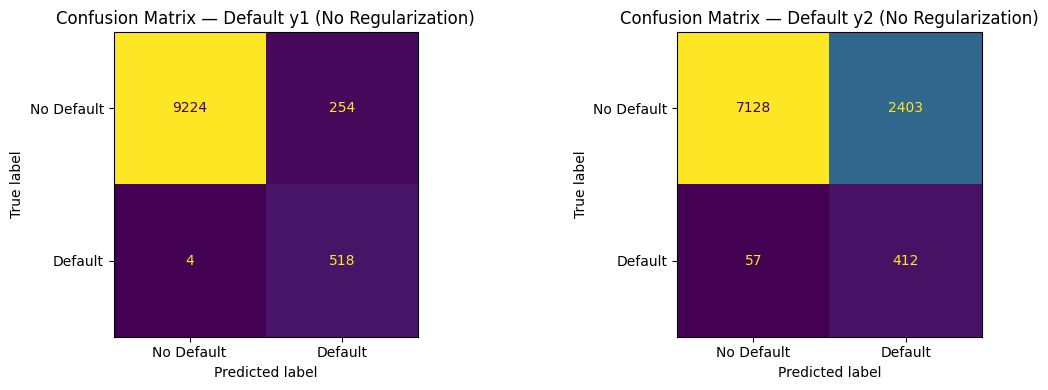

  CROSS-ENTROPY LOSS SUMMARY  (DF_train)
    Target  Cross-Entropy Loss
Default y1            0.929926
Default y2            8.866739


In [14]:
# ============================================================
# Part 3a: Logistic Regression Models-- TEST DATA
# ============================================================


# ------------------------------------------------------------
# Fit logistic regression on Dataset 1
# ------------------------------------------------------------
print("="*55)
print("DATASET TEST Y1 and Y2 - Logistic Regression")
print("="*55)


# ============================================================
# STEP 1: Define Features (X) and Targets (y)
# ============================================================


FEATURE_COLS = ['Age', 'Income (CHF k)', 'Self-Employed']
#'Default Prob p1', 'Default Prob p2']

TARGET_Y1    = 'Default y1'
TARGET_Y2    = 'Default y2'


#training data

X_train = df_Train[FEATURE_COLS]
y1_train = df_Train[TARGET_Y1]
y2_train = df_Train[TARGET_Y2]

# TEST DATA
X_test = df_Test[FEATURE_COLS]
y1_test = df_Test[TARGET_Y1]
y2_test = df_Test[TARGET_Y2]

# ============================================================
# STEP 3a: Individual Models — NO REGULARIZATION  ← CHANGED
# ============================================================


model_y1.fit(X_test, y1_test)
model_y2.fit(X_test, y2_test)

# ============================================================
# STEP 4: Predictions on TEST Data
# Replace X_train_scaled with scaler.transform(X_test) for
# evaluation on unseen data
# ============================================================
y1_Test_pred       = model_y1.predict(X_test)
y1_Test_pred_proba = model_y1.predict_proba(X_test)[:, 1]  # P(Default y1=1)

y2_Test_pred       = model_y2.predict(X_test)
y2_Test_pred_proba = model_y2.predict_proba(X_test)[:, 1]  # P(Default y2=1)

# ============================================================
# STEP 5: Evaluation
# ============================================================
for label, y_true, y_pred, y_proba in [
    ('Default y1', y1_test, y1_Test_pred, y1_Test_pred_proba),
    ('Default y2', y2_test, y2_Test_pred, y2_Test_pred_proba),
]:
    print(f"\n{'='*55}")
    print(f"  MODEL: {label}  |  penalty=None")
    print(f"{'='*55}")
    print(classification_report(y_true, y_pred,
                                 target_names=['No Default (0)', 'Default (1)']))
    print(f"  ROC-AUC Score: {roc_auc_score(y_true, y_proba):.4f}")
    print(f"  Actual Defaults: {y_true.sum():>6}")
    print(f"  Predicted Defaults: {y_pred.sum():>3}")
    print(f"  Actual Non-Defaults: {(y_true == 0).sum():>2}")
    print(f"  Predicted Non-Defaults: {(y_pred == 0).sum():>2}")

# ============================================================
# STEP 6: Confusion Matrices (visual)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, label, y_true, y_pred in [
    (axes[0], 'Default y1', y1_test, y1_Test_pred),
    (axes[1], 'Default y2', y2_test, y2_Test_pred),
]:
    ConfusionMatrixDisplay(
        confusion_matrix(y_true, y_pred),
        display_labels=['No Default', 'Default']
    ).plot(ax=ax, colorbar=False)
    ax.set_title(f'Confusion Matrix — {label} (No Regularization)')

plt.tight_layout()
plt.show()

# ============================================================
# STEP 7: Add predicted probabilities back to DF_Test
# ============================================================
# df_Train['y1_pred']       = y1_Test_pred
#df_Train['y1_pred_proba'] = np.round(y1_Test_pred_proba, 4)
#df_Train['y2_pred']       = y2_Test_pred
#df_Train['y2_pred_proba'] = np.round(y2_Test_pred_proba, 4)

#print("\n✅ Predicted labels and probabilities added to DF_TEST.")
#print(df_Train[['Default y1', 'y1_pred', 'y1_pred_proba',
#                 'Default y2', 'y2_pred', 'y2_pred_proba']].head(10))


# ============================================================
# STEP 8: Compute Binary Cross-Entropy Loss per target
#
# ============================================================
ce_y1_Test = log_loss(y1_test, y1_Test_pred)
ce_y2_Test = log_loss(y2_test, y2_Test_pred)

# ============================================================
# STEP 9: Summary Table
# ============================================================
ce_summary = pd.DataFrame({
    'Target':              ['Default y1', 'Default y2'],
    'Cross-Entropy Loss':  [round(ce_y1_Test, 6), round(ce_y2_Test, 6)],
})

print("=" * 45)
print("  CROSS-ENTROPY LOSS SUMMARY  (DF_train)")
print("=" * 45)
print(ce_summary.to_string(index=False))

### Visualizing the Regression Divide (Decision Boundaries)
The following plots show the logistic regression decision boundaries ($p=0.5$) overlaid on the actual data points.
Note: For these 2D visualizations, we hold 'Self-Employed' at 0 (Salaried) to show the relationship between Age and Income.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LogisticRegression was fitted with feature names

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LogisticRegression was fitted with feature names

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LogisticRegression was fitted with feature names

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LogisticRegression was fitted with feature names



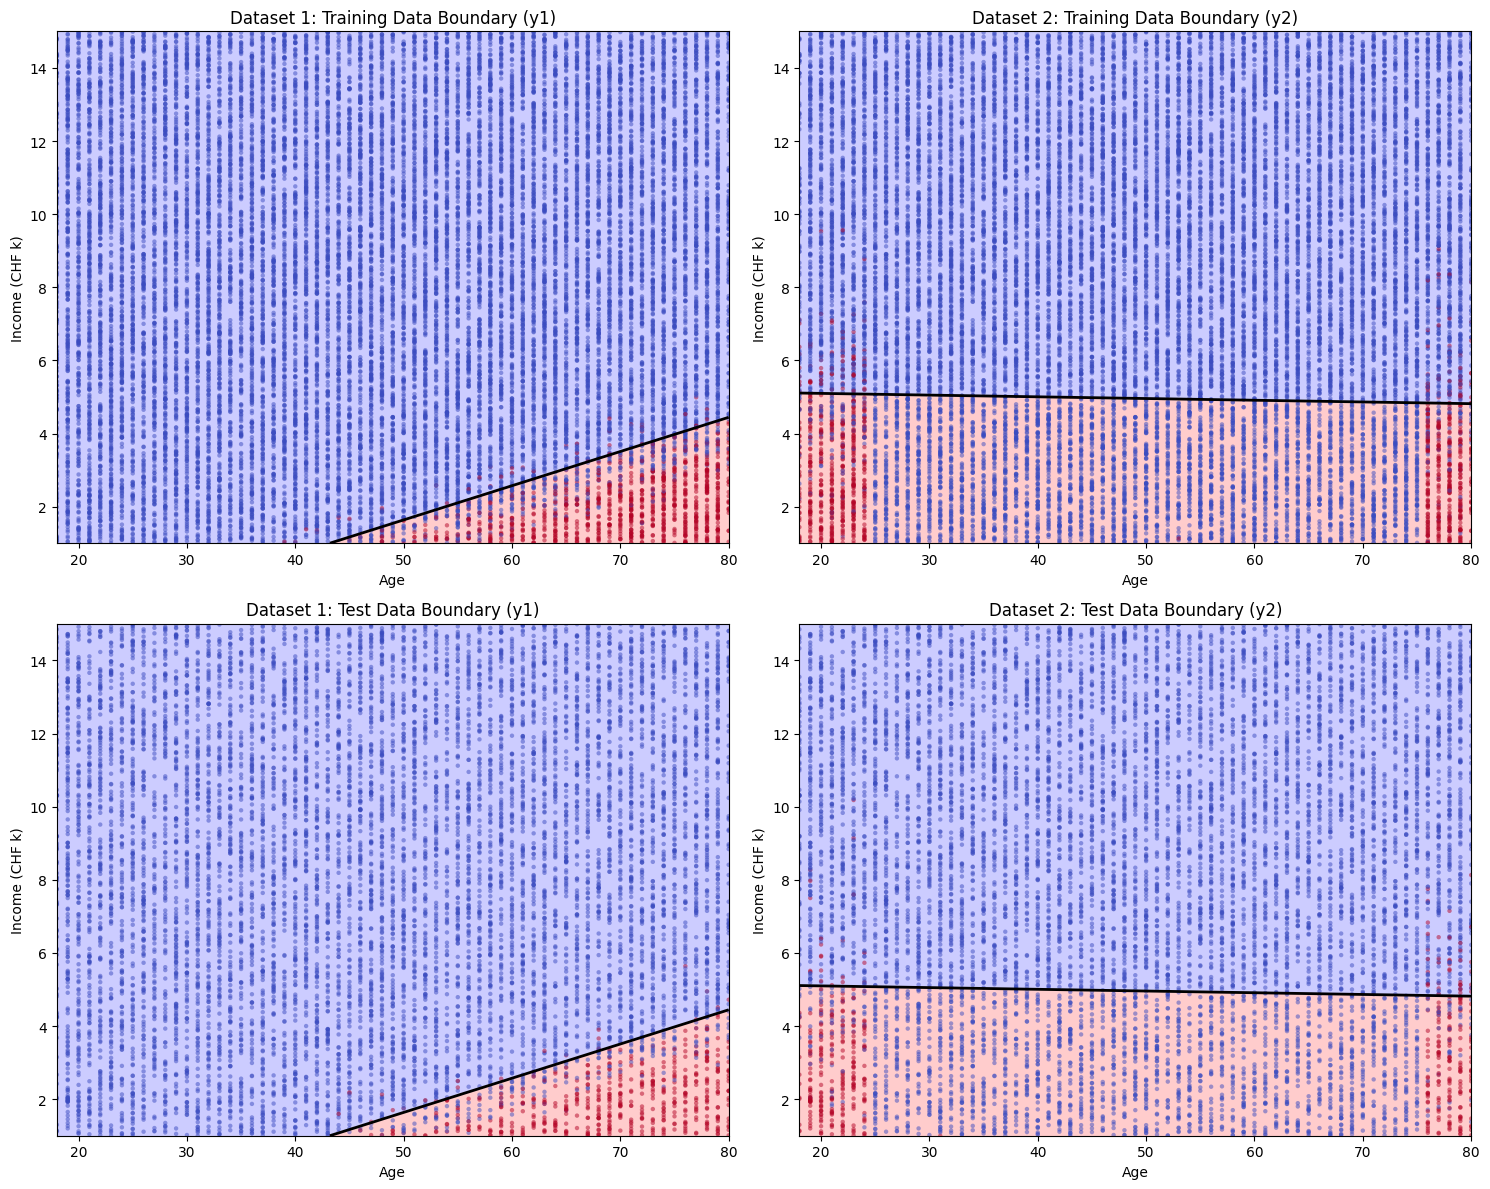

In [15]:
def plot_decision_boundary(model, X_data, y_true, title, ax):
    # Create a grid to plot the decision boundary
    x_min, x_max = 18, 80
    y_min, y_max = 1, 15
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

    # Prepare grid data: Age, Income, and assume Self-Employed=0
    grid_data = np.c_[xx.ravel(), yy.ravel(), np.zeros(xx.ravel().shape)]
    Z = model.predict_proba(grid_data)[:, 1]
    Z = Z.reshape(xx.shape)

    # Plot boundary
    contour = ax.contourf(xx, yy, Z, levels=[0, 0.5, 1], alpha=0.2, colors=['blue', 'red'])
    ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)

    # Plot actual data points (subset for visibility if needed)
    scatter = ax.scatter(X_data.iloc[:, 0], X_data.iloc[:, 1], c=y_true, cmap='coolwarm', s=10, alpha=0.5, edgecolors='none')

    ax.set_title(title)
    ax.set_xlabel('Age')
    ax.set_ylabel('Income (CHF k)')
    return scatter

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Training Data Plots
plot_decision_boundary(model_y1, X_train, y1_train, 'Dataset 1: Training Data Boundary (y1)', axes[0, 0])
plot_decision_boundary(model_y2, X_train, y2_train, 'Dataset 2: Training Data Boundary (y2)', axes[0, 1])

# Test Data Plots
plot_decision_boundary(model_y1, X_test, y1_test, 'Dataset 1: Test Data Boundary (y1)', axes[1, 0])
plot_decision_boundary(model_y2, X_test, y2_test, 'Dataset 2: Test Data Boundary (y2)', axes[1, 1])

plt.tight_layout()
plt.show()

### 3b) Neural network (NN)

Fit a neural network2 (NN) model

 ˆ pNN
s : R3 →R on the training data (xi,yi
s), i= 1,...,m.

To make the network output the conditional default probabilities, choose the sigmoid function ψ as activation function for the last layer and train the network by minimizing the cross-entropy.

In [ ]:
# Implement and train a neural network model
# You can use Keras (see the notebook "Project 1 - Credit risk - Sandbox")
# For more information, see: https://keras.io/getting_started/

@Jay - same here - I generated all in one go - but the template breaks it up differently. Would you please have a look at that and break it up accordingly?

In [16]:
# ============================================================
# Part 3b: Neural Network Models
# ============================================================
# NOTE: Run this AFTER the data generation code block.
# All variables (X_train, X_test, y1_train, y1_test,
# y2_train, y2_test) must already exist in your Colab session.
# The logistic regression variables (prob_lr1_test,
# prob_lr2_test) are also needed for the combined ROC plot.
# ============================================================

# --- Library imports ---


import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import log_loss, roc_curve, auc

# Fix random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)


FEATURE_COLS = ['Age', 'Income (CHF k)', 'Self-Employed']

TARGET_Y1    = 'Default y1'
TARGET_Y2    = 'Default y2'

X_NNtrain = df_Train[FEATURE_COLS]
y1_NNtrain = df_Train[TARGET_Y1]
y2_NNtrain = df_Train[TARGET_Y2]

#print(X_NNtrain.head)  # Check the contents of the Training Params dataset

X_NNtest = df_Test[FEATURE_COLS]
y1_NNtest = df_Test[TARGET_Y1]
y2_NNtest = df_Test[TARGET_Y2]

#print(X_NNtest.head)  # Check the contents of the TEST Params dataset

# ============================================================
# HELPER FUNCTION: Build a neural network
# ============================================================

def build_network(neurons_per_layer=50, num_hidden_layers=2, learning_rate=0.01):
    model = keras.Sequential()
    model.add(keras.Input(shape=(3,))) # Number of Parameters in the Input Layer

    for _ in range(num_hidden_layers): # Loop to create variable numbers of hidden layers
        model.add(layers.Dense(neurons_per_layer, activation='relu'))

    model.add(layers.Dense(1, activation='sigmoid')) #Add the output layer- Sigmoid for default probability
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# ============================================================
# DATASET 1 - Neural Network
# ============================================================
print("="*55)
print("DATASET 1 - Neural Network")
print("="*55)
print("Architecture: 2 hidden layers, 50 neurons each, ReLU")
print("Training: 100 epochs, batch size 1024, learning rate 0.01")
print()

nn1 = build_network(neurons_per_layer=50, num_hidden_layers=2, learning_rate=0.01) # pass the hyperparameters
nn1.summary()
print()

# Train for the true value Y1.
history1 = nn1.fit(
    X_NNtrain, y1_NNtrain,
    epochs=100,
    batch_size=1024,
    validation_data=(X_NNtest, y1_NNtest),
    verbose=1
)

prob_nn1_train = nn1.predict(X_NNtrain, verbose=0).flatten()
prob_nn1_test  = nn1.predict(X_NNtest,  verbose=0).flatten()

loss_nn1_train = log_loss(y1_NNtrain, prob_nn1_train)
loss_nn1_test  = log_loss(y1_NNtest,  prob_nn1_test)

print(f"\nCross-entropy loss - Training: {loss_nn1_train:.4f}")
print(f"Cross-entropy loss - Test:     {loss_nn1_test:.4f}")

# ============================================================
# DATASET 2 - Neural Network
# ============================================================
print()
print("="*55)
print("DATASET 2 - Neural Network")
print("="*55)
print("Architecture: 2 hidden layers, 50 neurons each, ReLU")
print("Training: 100 epochs, batch size 1024, learning rate 0.01")
print()

nn2 = build_network(neurons_per_layer=50, num_hidden_layers=2, learning_rate=0.01)
# Train for the true value Y2.
history2 = nn2.fit(
    X_NNtrain, y2_NNtrain,
    epochs=100,
    batch_size=1024,
    validation_data=(X_NNtest, y2_NNtest),
    verbose=1
)

prob_nn2_train = nn2.predict(X_NNtrain, verbose=0).flatten()
prob_nn2_test  = nn2.predict(X_NNtest,  verbose=0).flatten()



DATASET 1 - Neural Network
Architecture: 2 hidden layers, 50 neurons each, ReLU
Training: 100 epochs, batch size 1024, learning rate 0.01



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 50)             │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,801 (10.94 KB)

 Trainable params: 2,801 (10.94 KB)

 Non-trainable params: 0 (0.00 B)


Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.8911 - loss: 0.6349 - val_accuracy: 0.9478 - val_loss: 0.3186
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9522 - loss: 0.1857 - val_accuracy: 0.9776 - val_loss: 0.1145
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9653 - loss: 0.0942 - val_accuracy: 0.9728 - val_loss: 0.0761
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9755 - loss: 0.0693 - val_accuracy: 0.9797 - val_loss: 0.0593
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9780 - loss: 0.0577 - val_accuracy: 0.9805 - val_loss: 0.0515
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9791 - loss: 0.0525 - val_accuracy: 0.9816 - val_loss: 0.0459
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9807 - loss: 0.0484 - val_accuracy: 0.9829 - val_loss: 0.0422
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9816 - loss: 0.0448 - val_accuracy: 0.9833 -

In [17]:
# Compute the cross-entropy loss on the training and test data.
loss_nn2_train = log_loss(y2_NNtrain, prob_nn2_train)
loss_nn2_test  = log_loss(y2_NNtest,  prob_nn2_test)

print(f"\nNN Cross-entropy loss - Training: {loss_nn2_train:.4f}")
print(f"NN Cross-entropy loss - Test:     {loss_nn2_test:.4f}")




NN Cross-entropy loss - Training: 0.0565
NN Cross-entropy loss - Test:     0.0560


@ Jay - as mentioned - this is already done in code block above

### 3c) ROC curves and AUC scores

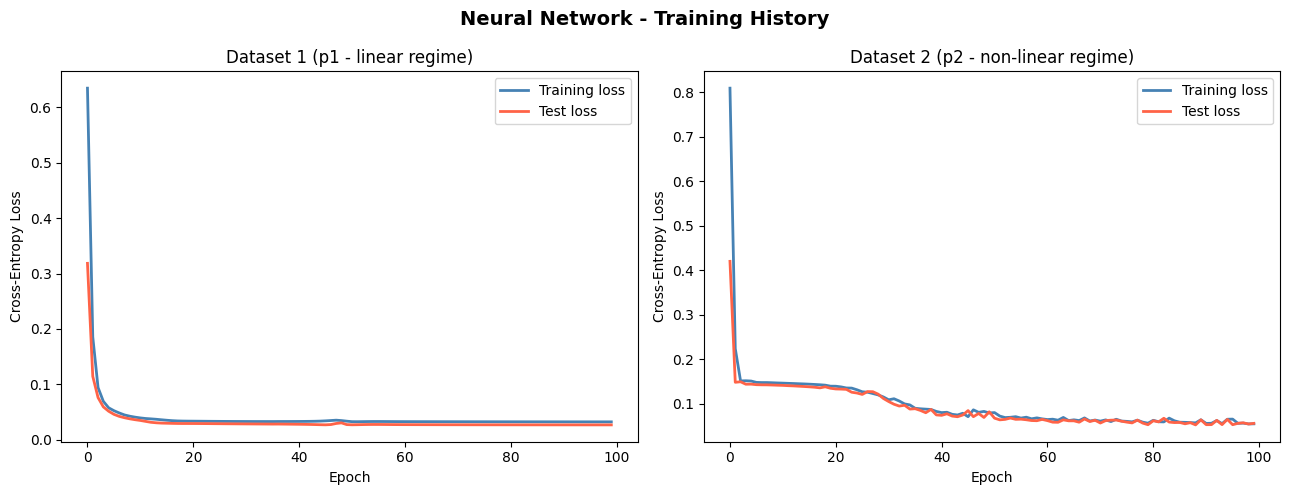

Saved: nn_training_history.png

Generating combined ROC curves...


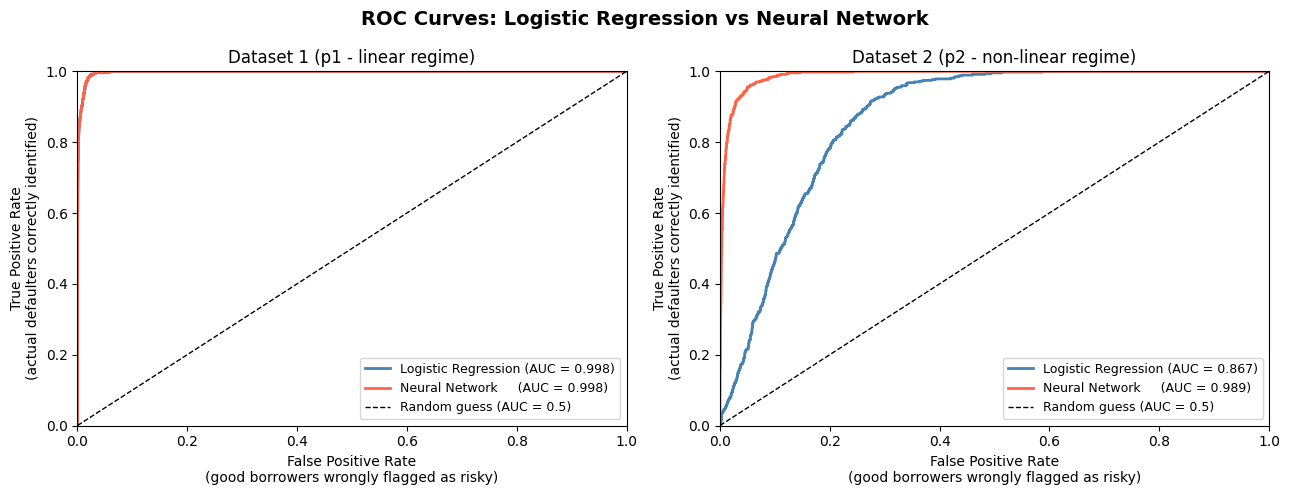

Saved: roc_comparison.png

SUMMARY: Cross-Entropy Loss, AUC, and Predicted Default Counts Comparison
Model                       DS1 Loss    DS1 AUC    DS1 Pred Def   DS2 Loss    DS2 AUC    DS2 Pred Def
-------------------------------------------------------------------------------------
Logistic Regression           0.0630     0.9978             772     0.4705     0.8675            2815
Neural Network                0.0268     0.9978             501     0.0560     0.9894             322

Actual Defaults (Test):    DS1:  522  | DS2:  469
INTERPRETATION HINT:
Compare the 'Pred Def' counts to the actual defaults to see if models are over/under-predicting.


In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, log_loss
import numpy as np

# ============================================================
# TRAINING HISTORY PLOTS
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Neural Network - Training History', fontsize=14, fontweight='bold')

for ax, history, label in zip(
    axes,
    [history1, history2],
    ['Dataset 1 (p1 - linear regime)', 'Dataset 2 (p2 - non-linear regime)']
):
    ax.plot(history.history['loss'],     label='Training loss', color='steelblue', linewidth=2)
    ax.plot(history.history['val_loss'], label='Test loss',     color='tomato',    linewidth=2)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Cross-Entropy Loss')
    ax.set_title(label)
    ax.legend()

plt.tight_layout()
plt.savefig('nn_training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: nn_training_history.png")

# ============================================================
# COMBINED ROC CURVES: Logistic Regression vs Neural Network
# ============================================================

print("\nGenerating combined ROC curves...")

# Predictions for Summary Metrics
y1_lr_pred = (y1_Test_pred_proba >= 0.5).astype(int)
y2_lr_pred = (y2_Test_pred_proba >= 0.5).astype(int)
y1_nn_pred = (prob_nn1_test >= 0.5).astype(int)
y2_nn_pred = (prob_nn2_test >= 0.5).astype(int)

fpr_nn1, tpr_nn1, _ = roc_curve(y1_NNtest, prob_nn1_test)
fpr_nn2, tpr_nn2, _ = roc_curve(y2_NNtest, prob_nn2_test)
auc_nn1 = auc(fpr_nn1, tpr_nn1)
auc_nn2 = auc(fpr_nn2, tpr_nn2)

fpr_lr1, tpr_lr1, _ = roc_curve(y1_test, y1_Test_pred_proba)
fpr_lr2, tpr_lr2, _ = roc_curve(y2_test, y2_Test_pred_proba)
auc_lr1 = auc(fpr_lr1, tpr_lr1)
auc_lr2 = auc(fpr_lr2, tpr_lr2)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('ROC Curves: Logistic Regression vs Neural Network',
             fontsize=14, fontweight='bold')

datasets = [
    ('Dataset 1 (p1 - linear regime)',
     fpr_lr1, tpr_lr1, auc_lr1, fpr_nn1, tpr_nn1, auc_nn1),
    ('Dataset 2 (p2 - non-linear regime)',
     fpr_lr2, tpr_lr2, auc_lr2, fpr_nn2, tpr_nn2, auc_nn2),
]

for ax, (title, fpr_lr, tpr_lr, auc_lr, fpr_nn, tpr_nn, auc_nn) in zip(axes, datasets):
    ax.plot(fpr_lr, tpr_lr, color='steelblue', linewidth=2,
            label=f'Logistic Regression (AUC = {auc_lr:.3f})')
    ax.plot(fpr_nn, tpr_nn, color='tomato',    linewidth=2,
            label=f'Neural Network     (AUC = {auc_nn:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random guess (AUC = 0.5)')
    ax.set_xlabel('False Positive Rate\n(good borrowers wrongly flagged as risky)')
    ax.set_ylabel('True Positive Rate\n(actual defaulters correctly identified)')
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('roc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: roc_comparison.png")

# ============================================================
# SUMMARY TABLE
# ============================================================
print()
print("="*85)
print("SUMMARY: Cross-Entropy Loss, AUC, and Predicted Default Counts Comparison")
print("="*85)
print(f"{'Model':<25} {'DS1 Loss':>10} {'DS1 AUC':>10} {'DS1 Pred Def':>15} {'DS2 Loss':>10} {'DS2 AUC':>10} {'DS2 Pred Def':>15}")
print(f"-"*85)
print(f"{'Logistic Regression':<25} {log_loss(y1_test, y1_Test_pred_proba):>10.4f} {auc_lr1:>10.4f} {y1_lr_pred.sum():>15} {log_loss(y2_test, y2_Test_pred_proba):>10.4f} {auc_lr2:>10.4f} {y2_lr_pred.sum():>15}")
print(f"{'Neural Network':<25} {loss_nn1_test:>10.4f} {auc_nn1:>10.4f} {y1_nn_pred.sum():>15} {loss_nn2_test:>10.4f} {auc_nn2:>10.4f} {y2_nn_pred.sum():>15}")
print()
print("Actual Defaults (Test):    DS1: ", y1_test.sum(), " | DS2: ", y2_test.sum())
print("="*85)
print("INTERPRETATION HINT:")
print("Compare the 'Pred Def' counts to the actual defaults to see if models are over/under-predicting.")

@ Jay - as mentioned - this is already done in code block above



(Bonus Excersise) - Hyperparameter tuning with Keras Tuner

Use a hyperparameter tuner (or hypertuner ) to find optimal parameters for: network depth, hidden nodes, inner activation function, learning rate.

See e.g. https://www.tensorflow.org/tutorials/keras/keras_tuner.

The Tuner will look for:

- Number of hidden layers: 1, 2, or 3 (how deep should the network be?)

- Neurons per layer: 16, 32, 64, or 128  (how wide should each layer be?)
- Activation function: ReLU or tanh  (which "bending rule" should each neuron use?)
- Learning rate: 0.001, 0.005, or 0.01 (how big a step should the model take each update?)

The tuner will try many combinations and keep the best one.


In [ ]:
# ============================================================
# Bonus excersise - Hyperparameter tuning with Keras Tuner
# ============================================================

# --- Install keras-tuner if not already available ---
# This only needs to run once in your Colab session
import subprocess
subprocess.run(["pip", "install", "keras-tuner", "-q"])

# --- Library imports ---
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_tuner as kt
from sklearn.metrics import log_loss, roc_curve, auc

np.random.seed(42)
tf.random.set_seed(42)


def build_tunable_model(hp):
    """
    This function defines the search space for the tuner.
    hp = hyperparameter object (the tuner fills this in)
    """
    model = keras.Sequential()
    model.add(keras.Input(shape=(3,)))

    # Search over number of hidden layers: 1, 2, or 3
    num_layers = hp.Int('num_layers', min_value=1, max_value=3, step=1)

    # Search over neurons per layer: 16, 32, 64, 128
    units = hp.Choice('units_per_layer', values=[16, 32, 64, 128])

    # Search over activation function: relu or tanh
    activation = hp.Choice('activation', values=['relu', 'tanh'])

    for _ in range(num_layers):
        model.add(layers.Dense(units, activation=activation))

    # Output layer is always sigmoid
    model.add(layers.Dense(1, activation='sigmoid'))

    # Search over learning rate
    learning_rate = hp.Choice('learning_rate', values=[0.001, 0.005, 0.01])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# ============================================================
# RUN TUNER ON DATASET 1
# ============================================================
print("="*55)
print("DATASET 1 - Hyperparameter Tuning")
print("="*55)
print("The tuner will try different combinations of:")
print("  - Number of layers (1-3)")
print("  - Neurons per layer (16, 32, 64, 128)")
print("  - Activation function (relu or tanh)")
print("  - Learning rate (0.001, 0.005, 0.01)")
print()

# RandomSearch: tries random combinations from the search space
# max_trials = how many different combinations to try
# We use val_loss (test loss) to decide which model is best
tuner1 = kt.RandomSearch(
    build_tunable_model,
    objective='val_loss',       # minimise loss on test data
    max_trials=20,              # try 20 different combinations
    executions_per_trial=1,     # train each combination once
    directory='tuner_ds1',      # save results here
    project_name='credit_ds1',
    overwrite=True
)

# Run the search
# epochs=50 per trial keeps it reasonably fast
tuner1.search(
    X_train, y1_train,
    epochs=50,
    batch_size=1024,
    validation_data=(X_test, y1_test),
    verbose=0   # silent to keep output clean
)

# Get the best hyperparameters found
best_hp1 = tuner1.get_best_hyperparameters(num_trials=1)[0]

print("Best hyperparameters found for Dataset 1:")
print(f"  Number of layers:    {best_hp1.get('num_layers')}")
print(f"  Neurons per layer:   {best_hp1.get('units_per_layer')}")
print(f"  Activation function: {best_hp1.get('activation')}")
print(f"  Learning rate:       {best_hp1.get('learning_rate')}")

# Train the best model fully for 100 epochs
print("\nRetraining best model for 100 epochs...")
best_nn1 = tuner1.hypermodel.build(best_hp1)
history_best1 = best_nn1.fit(
    X_train, y1_train,
    epochs=100,
    batch_size=1024,
    validation_data=(X_test, y1_test),
    verbose=0
)

prob_best_nn1_train = best_nn1.predict(X_train, verbose=0).flatten()
prob_best_nn1_test  = best_nn1.predict(X_test,  verbose=0).flatten()

loss_best_nn1_train = log_loss(y1_train, prob_best_nn1_train)
loss_best_nn1_test  = log_loss(y1_test,  prob_best_nn1_test)

print(f"Cross-entropy loss - Training: {loss_best_nn1_train:.4f}")
print(f"Cross-entropy loss - Test:     {loss_best_nn1_test:.4f}")

# ============================================================
# RUN TUNER ON DATASET 2
# ============================================================
print()
print("="*55)
print("DATASET 2 - Hyperparameter Tuning")
print("="*55)

tuner2 = kt.RandomSearch(
    build_tunable_model,
    objective='val_loss',
    max_trials=20,
    executions_per_trial=1,
    directory='tuner_ds2',
    project_name='credit_ds2',
    overwrite=True
)

tuner2.search(
    X_train, y2_train,
    epochs=50,
    batch_size=1024,
    validation_data=(X_test, y2_test),
    verbose=0
)

best_hp2 = tuner2.get_best_hyperparameters(num_trials=1)[0]

print("Best hyperparameters found for Dataset 2:")
print(f"  Number of layers:    {best_hp2.get('num_layers')}")
print(f"  Neurons per layer:   {best_hp2.get('units_per_layer')}")
print(f"  Activation function: {best_hp2.get('activation')}")
print(f"  Learning rate:       {best_hp2.get('learning_rate')}")

print("\nRetraining best model for 100 epochs...")
best_nn2 = tuner2.hypermodel.build(best_hp2)
history_best2 = best_nn2.fit(
    X_train, y2_train,
    epochs=100,
    batch_size=1024,
    validation_data=(X_test, y2_test),
    verbose=0
)

prob_best_nn2_train = best_nn2.predict(X_train, verbose=0).flatten()
prob_best_nn2_test  = best_nn2.predict(X_test,  verbose=0).flatten()

loss_best_nn2_train = log_loss(y2_train, prob_best_nn2_train)
loss_best_nn2_test  = log_loss(y2_test,  prob_best_nn2_test)

print(f"Cross-entropy loss - Training: {loss_best_nn2_train:.4f}")
print(f"Cross-entropy loss - Test:     {loss_best_nn2_test:.4f}")

# ============================================================
# COMPARISON: Default NN vs Tuned NN
# ============================================================
# We want to show whether tuning actually improved things

print()
print("="*55)
print("COMPARISON: Default NN vs Tuned NN")
print("="*55)

# Reload default NN losses from previous cell
# (these variables must exist from the previous code block)
print(f"{'Model':<30} {'DS1 Test Loss':>15} {'DS2 Test Loss':>15}")
print(f"{'Default NN (2L, 50n, ReLU)':<30} {loss_nn1_test:>15.4f} {loss_nn2_test:>15.4f}")
print(f"{'Tuned NN':<30} {loss_best_nn1_test:>15.4f} {loss_best_nn2_test:>15.4f}")

# ============================================================
# ROC CURVES: Default NN vs Tuned NN
# ============================================================

fpr_bnn1, tpr_bnn1, _ = roc_curve(y1_test, prob_best_nn1_test)
fpr_bnn2, tpr_bnn2, _ = roc_curve(y2_test, prob_best_nn2_test)
auc_bnn1 = auc(fpr_bnn1, tpr_bnn1)
auc_bnn2 = auc(fpr_bnn2, tpr_bnn2)

# Recompute default NN ROC for reference
fpr_nn1, tpr_nn1, _ = roc_curve(y1_test, prob_nn1_test)
fpr_nn2, tpr_nn2, _ = roc_curve(y2_test, prob_nn2_test)
auc_nn1 = auc(fpr_nn1, tpr_nn1)
auc_nn2 = auc(fpr_nn2, tpr_nn2)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('ROC Curves: Default NN vs Tuned NN',
             fontsize=14, fontweight='bold')

datasets = [
    ('Dataset 1 (p1 - linear regime)',
     fpr_nn1, tpr_nn1, auc_nn1, fpr_bnn1, tpr_bnn1, auc_bnn1),
    ('Dataset 2 (p2 - non-linear regime)',
     fpr_nn2, tpr_nn2, auc_nn2, fpr_bnn2, tpr_bnn2, auc_bnn2),
]

for ax, (title, fpr_d, tpr_d, auc_d, fpr_t, tpr_t, auc_t) in zip(axes, datasets):
    ax.plot(fpr_d, tpr_d, color='steelblue', linewidth=2,
            label=f'Default NN (AUC = {auc_d:.3f})')
    ax.plot(fpr_t, tpr_t, color='tomato',    linewidth=2,
            label=f'Tuned NN   (AUC = {auc_t:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random guess (AUC = 0.5)')
    ax.set_xlabel('False Positive Rate\n(good borrowers wrongly flagged as risky)')
    ax.set_ylabel('True Positive Rate\n(actual defaulters correctly identified)')
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('roc_tuned_nn.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: roc_tuned_nn.png")

print()
print("INTERPRETATION HINT FOR YOUR REPORT:")
print("If the tuned NN improves on Dataset 2, it suggests the")
print("default architecture was not quite optimal for capturing")
print("the non-linear U-shaped age pattern.")
print("If both are similar, it suggests 2 layers of 50 neurons")
print("was already a reasonable choice for this problem size.")


DATASET 1 - Hyperparameter Tuning
The tuner will try different combinations of:
  - Number of layers (1-3)
  - Neurons per layer (16, 32, 64, 128)
  - Activation function (relu or tanh)
  - Learning rate (0.001, 0.005, 0.01)

Best hyperparameters found for Dataset 1:
  Number of layers:    2
  Neurons per layer:   32
  Activation function: tanh
  Learning rate:       0.01

Retraining best model for 100 epochs...
Cross-entropy loss - Training: 0.0332
Cross-entropy loss - Test:     0.0276

DATASET 2 - Hyperparameter Tuning
Best hyperparameters found for Dataset 2:
  Number of layers:    3
  Neurons per layer:   64
  Activation function: relu
  Learning rate:       0.005

Retraining best model for 100 epochs...


KeyboardInterrupt: 

# Exercise 4. Comparison of lending strategies

In [ ]:
# Implement a function to compute the Value at Risk (VaR) at level alpha on the vector x

def var(x, alpha):
    # Write your code here and return your VaR(alpha) estimate
    return None

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ============================================================
# Fix for NameError: Ensure y2_test and other dependencies are defined
# ============================================================
# Assumes 'df_Test' is already loaded from previous cells (e.g., teR4EI8aymKG)
if 'df_Test' not in globals():
    raise NameError("DataFrame 'df_Test' is not defined. Please ensure prior data loading and splitting cells (e.g., 'teR4EI8aymKG') have been executed.")

# Define TARGET_Y2 if not globally available
if 'TARGET_Y2' not in globals():
    TARGET_Y2 = 'Default y2'

# Re-define y2_test using df_Test if it's not in global scope
if 'y2_test' not in globals():
    y2_test = df_Test[TARGET_Y2]

# Re-define prob_lr2_test (which corresponds to y2_Test_pred_proba) if not in global scope
if 'prob_lr2_test' not in globals():
    if 'y2_Test_pred_proba' in globals():
        prob_lr2_test = y2_Test_pred_proba
    else:
        print("Warning: 'y2_Test_pred_proba' (for Logistic Regression) not found. Setting 'prob_lr2_test' to zeros. Please run the Logistic Regression cells.")
        prob_lr2_test = np.zeros(len(y2_test)) # Placeholder to avoid NameError

# Re-define prob_nn2_test if not in global scope
if 'prob_nn2_test' not in globals():
    if 'nn2' in globals() and 'X_NNtest' in globals():
        try:
            prob_nn2_test = nn2.predict(X_NNtest,  verbose=0).flatten()
        except Exception as e:
            print(f"Warning: Could not re-predict 'prob_nn2_test' using 'nn2' and 'X_NNtest': {e}. Setting 'prob_nn2_test' to zeros.")
            prob_nn2_test = np.zeros(len(y2_test))
    else:
        print("Warning: 'nn2' or 'X_NNtest' (for Neural Network) not found. Setting 'prob_nn2_test' to zeros. Please run the Neural Network cells.")
        prob_nn2_test = np.zeros(len(y2_test)) # Placeholder to avoid NameError

# ============================================================
# STEP 1: SIMULATE 1000 MARKET SCENARIOS
# ============================================================
n_test      = len(y2_test)
n_scenarios = 1000

print("Simulating 1000 market scenarios...")
prob2_test = df_Test['Default Prob p2']
true_defaults = df_Test['Default y2']

D = np.random.binomial(
    n=1,
    p=prob2_test.to_numpy()[:, np.newaxis],
    size=(n_test, n_scenarios)
)

var_rate = 0.05

# ============================================================
# STEP 2: DEFINE THE THREE LENDING STRATEGIES
# ============================================================
loan_amount   = 100

rate_i        = 0.055
selected_i    = np.ones(n_test, dtype=bool)

rate_ii       = 0.01
selected_ii   = (prob_lr2_test <= var_rate)

rate_iii      = 0.01
selected_iii  = (prob_nn2_test <= var_rate)

# ============================================================
# STEP 3: CALCULATE PORTFOLIO P&L COMPONENTS
# ============================================================
def compute_portfolio_details(selected, interest_rate, default_matrix, true_labels):
    # Filter matrix to only selected borrowers
    D_sel = default_matrix[selected, :]
    y_true_sel = true_labels[selected]
    n_borrowers = D_sel.shape[0]

    # Simulation Components
    n_defaults_sim = D_sel.sum(axis=0)
    n_non_defaults_sim = n_borrowers - n_defaults_sim
    interest_income_sim = n_non_defaults_sim * loan_amount * interest_rate
    capital_loss_sim = n_defaults_sim * loan_amount
    total_pnl_sim = interest_income_sim - capital_loss_sim

    # True Label Components
    n_defaults_true = y_true_sel.sum()
    n_non_defaults_true = n_borrowers - n_defaults_true # Fixed: use n_defaults_true
    interest_income_true = n_non_defaults_true * loan_amount * interest_rate
    capital_loss_true = n_defaults_true * loan_amount
    total_pnl_true = interest_income_true - capital_loss_true

    return {
        'n_borrowers': n_borrowers,
        'total_pnl': total_pnl_sim,
        'n_defaults': n_defaults_sim,
        'n_non_defaults': n_non_defaults_sim,
        'interest_income': interest_income_sim,
        'capital_loss': capital_loss_sim,
        # Actuals
        'true_pnl': total_pnl_true,
        'true_defaults': n_defaults_true,
        'true_non_defaults': n_non_defaults_true,
        'true_interest': interest_income_true,
        'true_loss': capital_loss_true
    }


results_i = compute_portfolio_details(selected_i, rate_i, D, true_defaults.values)
results_ii = compute_portfolio_details(selected_ii, rate_ii, D, true_defaults.values)
results_iii = compute_portfolio_details(selected_iii, rate_iii, D, true_defaults.values)

def print_detailed_stats(res, strategy_name):
    # Expected Values (Mean across scenarios)
    exp_pnl = res['total_pnl'].mean()
    exp_def = res['n_defaults'].mean()
    exp_non = res['n_non_defaults'].mean()
    exp_int = res['interest_income'].mean()
    exp_loss = res['capital_loss'].mean()

    # 5% VaR Scenario
    var_idx = np.argsort(res['total_pnl'])[int(var_rate * n_scenarios)]

    print(f"{'='*82}")
    print(f"STRATEGY: {strategy_name} ({res['n_borrowers']} borrowers)")
    print(f"{'='*82}")
    print(f"{'Metric':<25} | {'Expected (Sim)':>15} | {'5% VaR Case':>15} | {'True Labels':>15}")
    print(f"-{'-'*80}")
    print(f"{'Non-Defaulting Loans':<25} | {exp_non:>15.0f} | {res['n_non_defaults'][var_idx]:>15.0f} | {res['true_non_defaults']:>15.0f}")
    print(f"{'Interest Income (CHF)':<25} | {exp_int:>15.2f} | {res['interest_income'][var_idx]:>15.2f} | {res['true_interest']:>15.2f}")
    print(f"{'Defaulting Loans':<25} | {exp_def:>15.0f} | {res['n_defaults'][var_idx]:>15.0f} | {res['true_defaults']:>15.0f}")
    print(f"{'Capital Loss (CHF)':<25} | {exp_loss:>15.2f} | {res['capital_loss'][var_idx]:>15.2f} | {res['true_loss']:>15.2f}")
    print(f"-{'-'*80}")
    print(f"{'TOTAL PORTFOLIO P&L':<25} | {exp_pnl:>15.2f} | {res['total_pnl'][var_idx]:>15.2f} | {res['true_pnl']:>15.2f}")
    # Added line for P&L per Applicant
    print(f"{'TOTAL PORTFL. P&L / Appl.':<25} | {exp_pnl / res['n_borrowers'] :>15.2f} | {res['total_pnl'][var_idx] / res['n_borrowers'] :>15.2f} | {res['true_pnl'] / res['n_borrowers'] :>15.2f}")
    print('\n')

print_detailed_stats(results_i, '(i) Lend All, 5.5%')
print_detailed_stats(results_ii, '(ii) Log. Regression Filter, 1%')
print_detailed_stats(results_iii, '(iii) Neural Network Filter, 1%')

pnl_i, pnl_ii, pnl_iii = results_i['total_pnl'], results_ii['total_pnl'], results_iii['total_pnl']

Simulating 1000 market scenarios...
STRATEGY: (i) Lend All, 5.5% (10000 borrowers)
Metric                    |  Expected (Sim) |     5% VaR Case |     True Labels
---------------------------------------------------------------------------------
Non-Defaulting Loans      |            9520 |            9502 |            9531
Interest Income (CHF)     |        52357.45 |        52261.00 |        52420.50
Defaulting Loans          |             480 |             498 |             469
Capital Loss (CHF)        |        48046.40 |        49800.00 |        46900.00
---------------------------------------------------------------------------------
TOTAL PORTFOLIO P&L       |         4311.05 |         2461.00 |         5520.50
TOTAL PORTFL. P&L / Appl. |            0.43 |            0.25 |            0.55


STRATEGY: (ii) Log. Regression Filter, 1% (3692 borrowers)
Metric                    |  Expected (Sim) |     5% VaR Case |     True Labels
----------------------------------------------------

In [ ]:
# Implement strategy (i), plot the P&L histogram and compute VaR(95%) of the losses

# Implement strategy (ii), plot the P&L histogram and compute VaR(95%) of the losses

# Implement strategy (iii), plot the P&L histogram and compute VaR(95%) of the losses

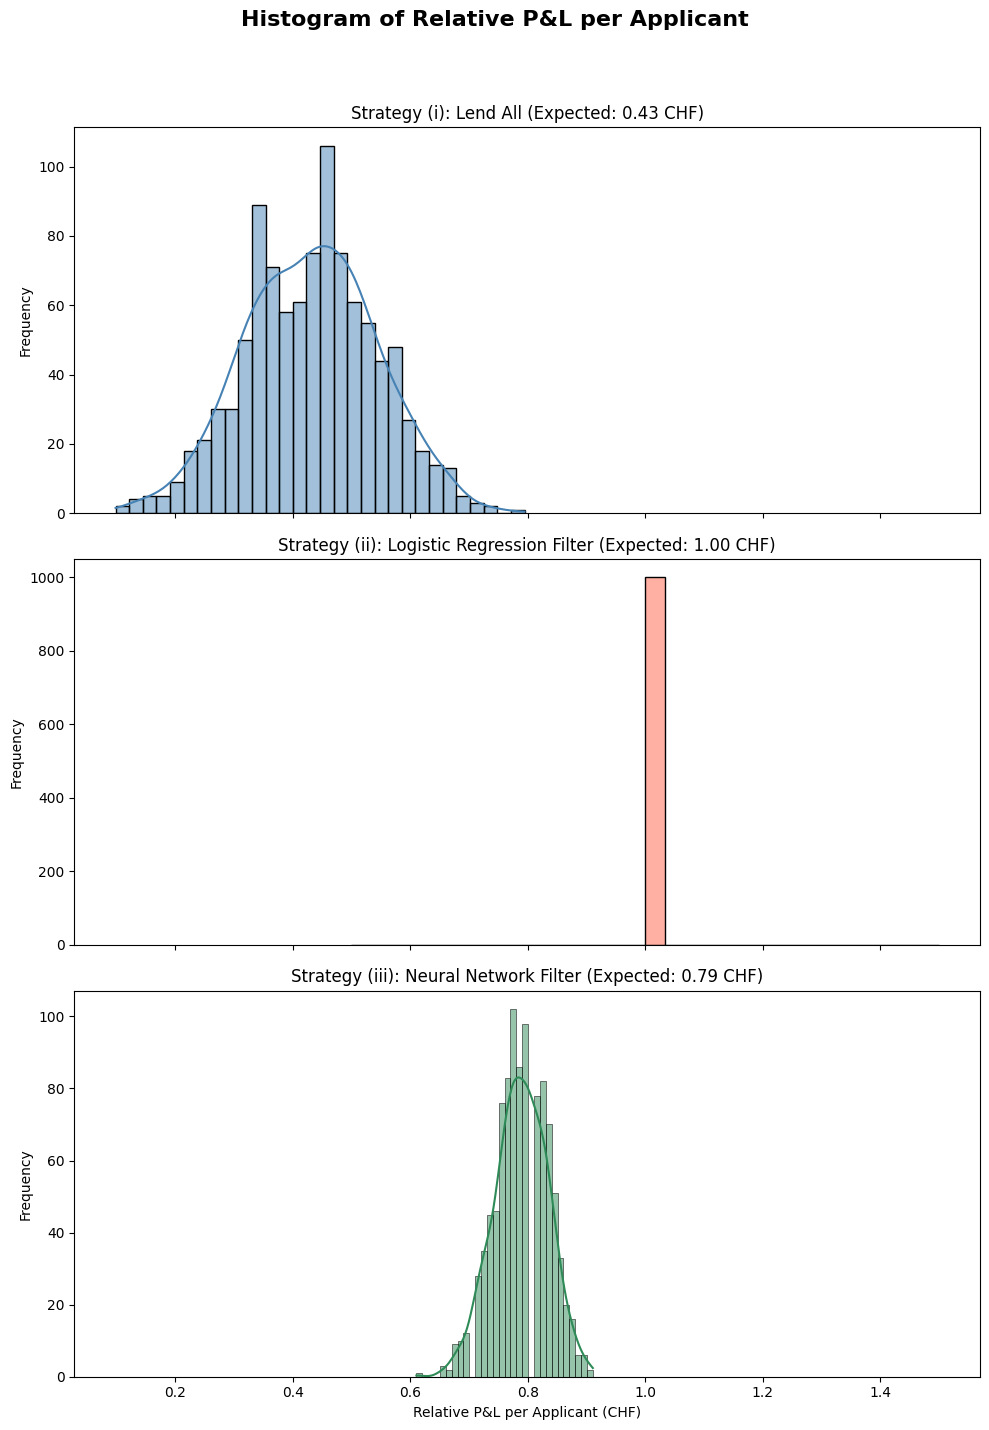

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare data for plotting
strat_i_norm = results_i['total_pnl'] / results_i['n_borrowers']
strat_ii_norm = results_ii['total_pnl'] / results_ii['n_borrowers']
strat_iii_norm = results_iii['total_pnl'] / results_iii['n_borrowers']

fig, axes = plt.subplots(3, 1, figsize=(10, 15), sharex=True)
fig.suptitle('Histogram of Relative P&L per Applicant', fontsize=16, fontweight='bold')

# Strategy (i)
sns.histplot(strat_i_norm, bins=30, ax=axes[0], color='steelblue', kde=True)
axes[0].set_title(f'Strategy (i): Lend All (Expected: {strat_i_norm.mean():.2f} CHF)')
axes[0].set_ylabel('Frequency')

# Strategy (ii)
sns.histplot(strat_ii_norm, bins=30, ax=axes[1], color='tomato', kde=True)
axes[1].set_title(f'Strategy (ii): Logistic Regression Filter (Expected: {strat_ii_norm.mean():.2f} CHF)')
axes[1].set_ylabel('Frequency')

# Strategy (iii)
sns.histplot(strat_iii_norm, bins=30, ax=axes[2], color='seagreen', kde=True)
axes[2].set_title(f'Strategy (iii): Neural Network Filter (Expected: {strat_iii_norm.mean():.2f} CHF)')
axes[2].set_xlabel('Relative P&L per Applicant (CHF)')
axes[2].set_ylabel('Frequency')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [21]:
### Calculate Normalized P&L per applicant

# Create a list of tuples: (P&L vector, borrower count, strategy name)
strategies_data = [
    (results_i['total_pnl'], results_i['n_borrowers'], "Strategy (i)"),
    (results_ii['total_pnl'], results_ii['n_borrowers'], "Strategy (ii)"),
    (results_iii['total_pnl'], results_iii['n_borrowers'], "Strategy (iii)")
]

print("Average Normalized P&L per Applicant (across 1000 scenarios):")
print("-" * 60)

for pnl_vec, n_borrowers, name in strategies_data:
    # Calculate per-applicant P&L for each scenario
    normalized_pnl = pnl_vec / n_borrowers

    # Calculate mean and standard deviation across scenarios
    avg_norm_pnl = normalized_pnl.mean()
    std_norm_pnl = normalized_pnl.std()

    print(f"{name:<15} | Mean P&L: {avg_norm_pnl:>6.2f} CHF | Std Dev: {std_norm_pnl:>6.2f}")

Average Normalized P&L per Applicant (across 1000 scenarios):
------------------------------------------------------------
Strategy (i)    | Mean P&L:   0.45 CHF | Std Dev:   0.12
Strategy (ii)   | Mean P&L:   1.00 CHF | Std Dev:   0.00
Strategy (iii)  | Mean P&L:   0.79 CHF | Std Dev:   0.04
